## Step 1 — Notebook Setup (Device, Seeds)

We set the device (GPU if available, else CPU), enable speed knobs, and fix the random seed for reproducibility.


In [1]:
import os, random, sys
from pathlib import Path
import numpy as np
import torch

# allow importing from ../src
sys.path.append(str(Path("..") / "src"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# speed & reproducibility
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if device.type == "cuda": torch.cuda.manual_seed_all(seed)


Torch: 2.8.0+cu129
Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Step 2 — Dataset Preparation

Annotations are split per image: e.g., `1001_exp.npy`, `1001_val.npy`, `1001_aro.npy`.
We:
1) read all `_exp`, `_val`, `_aro` files,
2) match them to images by numeric ID in the filename,
3) construct aligned arrays: `image_paths`, `expr`, `val`, `aro`,
4) run sanity checks and preview a sample.


In [3]:
from pathlib import Path
import numpy as np
import re
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = Path("../src/Dataset")
ANN_DIR  = DATA_DIR / "annotations"
IMG_DIR  = DATA_DIR / "images"

def load_ann_map(suffix: str):
    out = {}
    for p in ANN_DIR.glob(f"*_{suffix}.npy"):
        id_ = p.stem.split("_")[0]
        out[id_] = np.load(p, allow_pickle=True)
    return out

exp_map = load_ann_map("exp")
val_map = load_ann_map("val")
aro_map = load_ann_map("aro")

# map images by numeric ID at start of filename: "123.jpg" or "123_x.png"
img_map = {}
for p in list(IMG_DIR.glob("*.jpg")) + list(IMG_DIR.glob("*.png")):
    m = re.match(r"(\d+)", p.stem)
    if m:
        img_map[m.group(1)] = p

ids = sorted(set(exp_map) & set(val_map) & set(aro_map) & set(img_map), key=lambda x: int(x))
print("Matched samples:", len(ids))

def to_scalar(x):
    arr = np.array(x)
    if arr.ndim == 0: return float(arr.item())
    return float(arr.reshape(-1)[0])

def to_expr_label(x):
    arr = np.array(x)
    if arr.ndim == 0 or arr.size == 1: return int(arr.reshape(-1)[0])
    return int(np.argmax(arr))  # handle one-hot or score vector

image_paths = [img_map[i] for i in ids]
expr = np.array([to_expr_label(exp_map[i]) for i in ids], dtype=np.int64)
val  = np.array([to_scalar(val_map[i])     for i in ids], dtype=np.float32)
aro  = np.array([to_scalar(aro_map[i])     for i in ids], dtype=np.float32)

print("expr:", expr.shape, "classes (first 20):", sorted(set(expr[:20])))
print("val range:", float(val.min()), "→", float(val.max()))
print("aro range:", float(aro.min()), "→", float(aro.max()))


Matched samples: 3999
expr: (3999,) classes (first 20): [0, 1, 2, 4, 5, 6, 7]
val range: -0.9872239828109741 → 0.982384979724884
aro range: -0.6666669845581055 → 0.9841269850730896


### Visualizing a Sample

Display one image with its labels to confirm alignment.


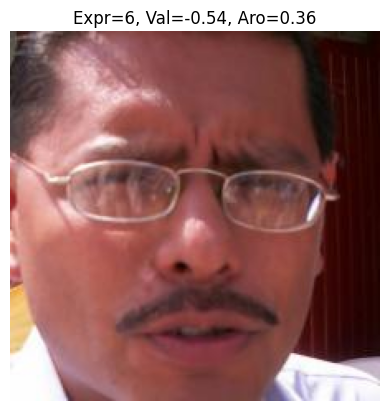

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

i = 10
img = Image.open(image_paths[i]).convert("RGB")
plt.imshow(img); plt.axis("off")
plt.title(f"Expr={expr[i]}, Val={val[i]:.2f}, Aro={aro[i]:.2f}")
plt.show()


## Step 3 — Dataset Class & DataLoaders

We wrap our aligned arrays into a PyTorch `Dataset`, apply light augmentations,
and create train/validation `DataLoader`s. Regression labels with value `-2`
are marked invalid and excluded from regression loss/metrics via a mask.


In [5]:
from torch.utils.data import DataLoader
from data.dataset import FacesDataset
from data.transforms import get_transforms

train_tfms, val_tfms = get_transforms()

# 80/20 split
N = len(image_paths)
idx = np.arange(N); np.random.seed(42); np.random.shuffle(idx)
cut = int(0.8*N); tr, va = idx[:cut], idx[cut:]

train_ds = FacesDataset([image_paths[i] for i in tr], expr[tr], val[tr], aro[tr], transform=train_tfms)
val_ds   = FacesDataset([image_paths[i] for i in va], expr[va], val[va], aro[va], transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

len(train_ds), len(val_ds)


(3199, 800)

## Step 4 — Training the Model (GPU/CPU with AMP)

- Optimizer: AdamW (lr=3e-4, wd=1e-4)
- Loss: CrossEntropy (classification) + λ * MSE (regression)
- Metrics each epoch: Accuracy, Macro-F1, RMSE, CCC, SAGR
- AMP enabled automatically on CUDA for speed; CPU falls back safely.


In [6]:
from models.multitask import MultiTaskNet
from train.engine import train_one_epoch, evaluate
from torch import optim
import torch

def run_training(backbone="resnet18", epochs=5, lambda_reg=1.0):
    model = MultiTaskNet(backbone=backbone, pretrained=True).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

    history = []
    for ep in range(1, epochs+1):
        tr = train_one_epoch(model, train_loader, optimizer, device, lambda_reg, scaler=scaler)
        va = evaluate(model, val_loader, device, lambda_reg)
        history.append({"epoch": ep, **{f"tr_{k}":v for k,v in tr.items()},
                                 **{f"va_{k}":v for k,v in va.items()}})
        print(f"[{ep:02d}] tr_loss={tr['loss']:.4f} | "
              f"val_acc={va['acc']:.3f} val_f1={va['f1_macro']:.3f} "
              f"val_rmse={va['rmse']:.3f} val_ccc={va['ccc']:.3f} val_sagr={va['sagr']:.3f}")
    return model, history

# Train baseline 1
resnet_model, resnet_hist = run_training("resnet18", epochs=5)

# Train baseline 2
effnet_model, effnet_hist = run_training("efficientnet_b0", epochs=5)


C:\Users\ramis\AppData\Local\Temp\ipykernel_16168\2236945892.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


[01] tr_loss=1.9849 | val_acc=0.351 val_f1=0.336 val_rmse=0.413 val_ccc=0.349 val_sagr=0.733


[02] tr_loss=1.3707 | val_acc=0.401 val_f1=0.384 val_rmse=0.403 val_ccc=0.388 val_sagr=0.741


[03] tr_loss=0.9732 | val_acc=0.395 val_f1=0.389 val_rmse=0.397 val_ccc=0.455 val_sagr=0.754


[04] tr_loss=0.6240 | val_acc=0.410 val_f1=0.395 val_rmse=0.445 val_ccc=0.389 val_sagr=0.742


...

[01] tr_loss=2.0963 | val_acc=0.318 val_f1=0.302 val_rmse=0.419 val_ccc=0.340 val_sagr=0.714


[02] tr_loss=1.5862 | val_acc=0.372 val_f1=0.369 val_rmse=0.396 val_ccc=0.368 val_sagr=0.746


[03] tr_loss=1.1755 | val_acc=0.403 val_f1=0.401 val_rmse=0.392 val_ccc=0.422 val_sagr=0.745


[04] tr_loss=0.8096 | val_acc=0.425 val_f1=0.425 val_rmse=0.412 val_ccc=0.410 val_sagr=0.730


[05] tr_loss=0.5211 | val_acc=0.400 val_f1=0.407 val_rmse=0.390 val_ccc=0.427 val_sagr=0.740


## Step 5 — Save Curves & Prepare Report Figures

We save training curves and will later add confusion matrix & PR curves (multi-class).
This gives us material for the PDF report and a clean comparison between backbones.


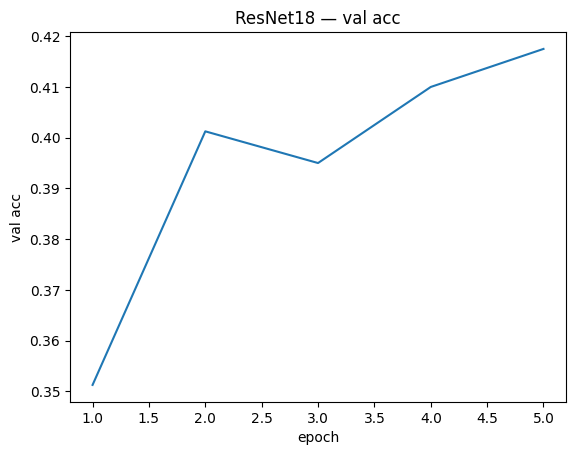

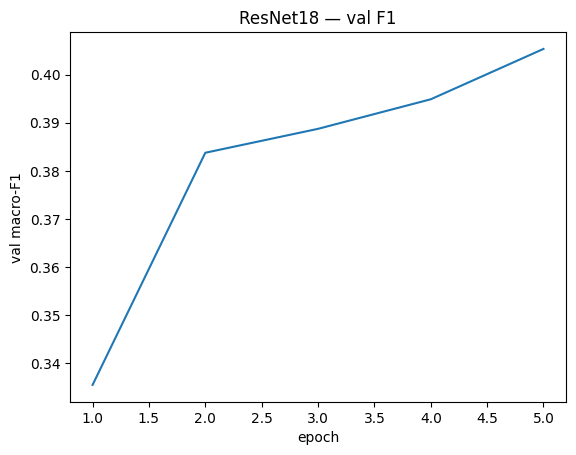

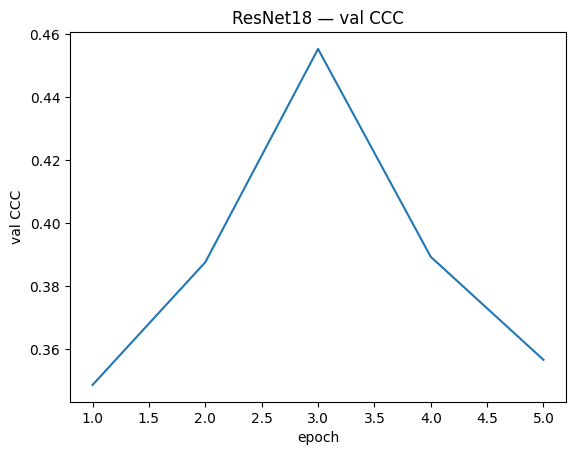

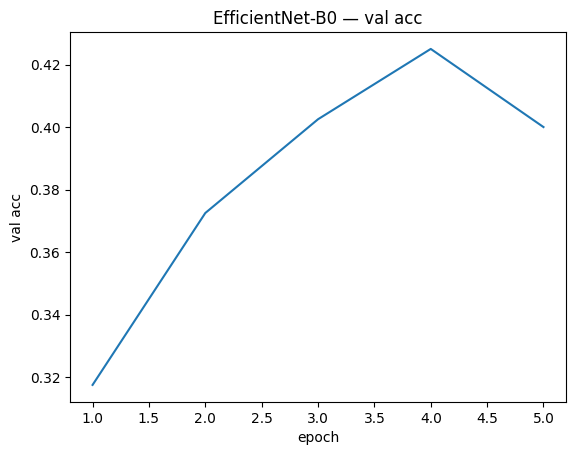

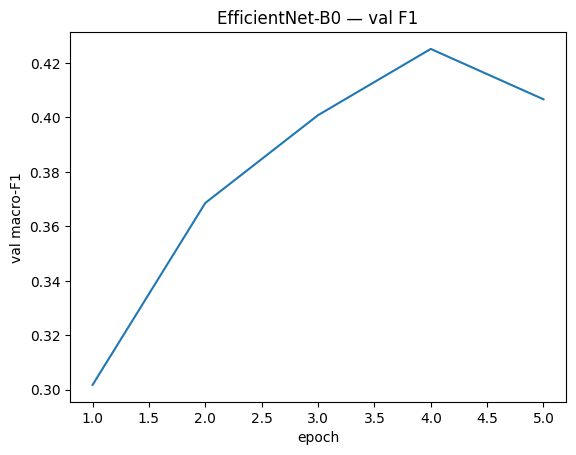

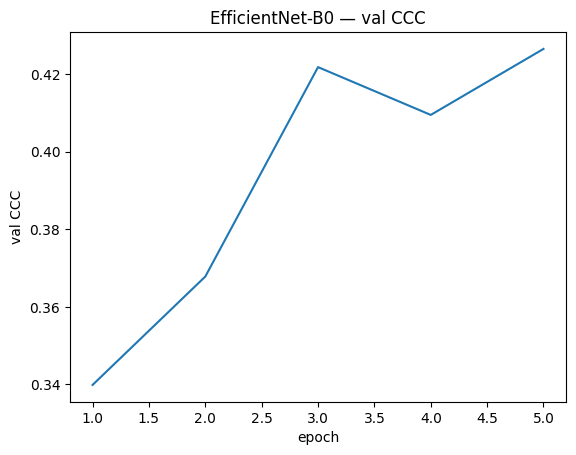

In [7]:
import matplotlib.pyplot as plt

def plot_history(hist, title):
    ep = [h["epoch"] for h in hist]
    acc = [h["va_acc"] for h in hist]
    f1  = [h["va_f1_macro"] for h in hist]
    ccc = [h["va_ccc"] for h in hist]

    plt.figure(); plt.plot(ep, acc); plt.xlabel("epoch"); plt.ylabel("val acc"); plt.title(title+" — val acc"); plt.show()
    plt.figure(); plt.plot(ep, f1);  plt.xlabel("epoch"); plt.ylabel("val macro-F1"); plt.title(title+" — val F1"); plt.show()
    plt.figure(); plt.plot(ep, ccc); plt.xlabel("epoch"); plt.ylabel("val CCC"); plt.title(title+" — val CCC"); plt.show()

plot_history(resnet_hist, "ResNet18")
plot_history(effnet_hist, "EfficientNet-B0")


## Step 6 — Extended Evaluation Metrics

We now compute:
- **Cohen’s Kappa (κ)**
- **Krippendorff’s Alpha (α)**
- **Macro AUC (ROC)**
- **Macro AUC-PR**

along with plots for confusion matrix, ROC curves, PR curves, and regression scatter plots.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

from utils.metrics import cohen_kappa, kripp_alpha, macro_auc, macro_auc_pr

def full_eval(model, loader, device, n_classes=8):
    model.eval()
    y_true, y_logits, y_reg_true, y_reg_pred, y_mask = [], [], [], [], []

    with torch.no_grad():
        for imgs, y_cls, y_reg, reg_ok, _ in loader:
            imgs = imgs.to(device)
            logits, reg = model(imgs)
            y_true.append(y_cls.numpy())
            y_logits.append(logits.cpu().numpy())
            y_reg_true.append(y_reg.numpy())
            y_reg_pred.append(reg.cpu().numpy())
            y_mask.append(reg_ok.numpy())

    y_true = np.concatenate(y_true)
    y_logits = np.concatenate(y_logits)
    y_pred = y_logits.argmax(1)
    y_reg_true = np.concatenate(y_reg_true)
    y_reg_pred = np.concatenate(y_reg_pred)
    y_mask = np.concatenate(y_mask).astype(bool)

    # classification extra metrics
    kappa = cohen_kappa(y_true, y_logits)
    alpha = kripp_alpha(y_true, y_logits, n_classes)
    auc   = macro_auc(y_true, y_logits, n_classes)
    aucpr = macro_auc_pr(y_true, y_logits, n_classes)

    print("Cohen’s Kappa:", kappa)
    print("Krippendorff’s Alpha:", alpha)
    print("Macro AUC:", auc)
    print("Macro AUC-PR:", aucpr)

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()

    # ROC curves
    y_true_oh = np.eye(n_classes)[y_true]
    for i in range(n_classes):
        if y_true_oh[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_logits[:, i])
            plt.plot(fpr, tpr, label=f"Class {i}")
    plt.plot([0,1],[0,1],'k--')
    plt.title("ROC Curves"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend(); plt.show()

    # PR curves
    for i in range(n_classes):
        if y_true_oh[:, i].sum() > 0:
            prec, rec, _ = precision_recall_curve(y_true_oh[:, i], y_logits[:, i])
            plt.plot(rec, prec, label=f"Class {i}")
    plt.title("PR Curves"); plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(); plt.show()

    # regression scatter plots (valence & arousal)
    if y_mask.sum() > 0:
        t = y_reg_true[y_mask]; p = y_reg_pred[y_mask]
        plt.scatter(t[:,0], p[:,0], alpha=0.3)
        plt.xlabel("True Valence"); plt.ylabel("Pred Valence")
        plt.title("Valence Scatter"); plt.show()

        plt.scatter(t[:,1], p[:,1], alpha=0.3)
        plt.xlabel("True Arousal"); plt.ylabel("Pred Arousal")
        plt.title("Arousal Scatter"); plt.show()


## Step 7 — Qualitative Analysis

To visualize model behavior:
- Show a grid of sample images where predictions are **correct** and **wrong**.
- This helps understand confusion patterns.


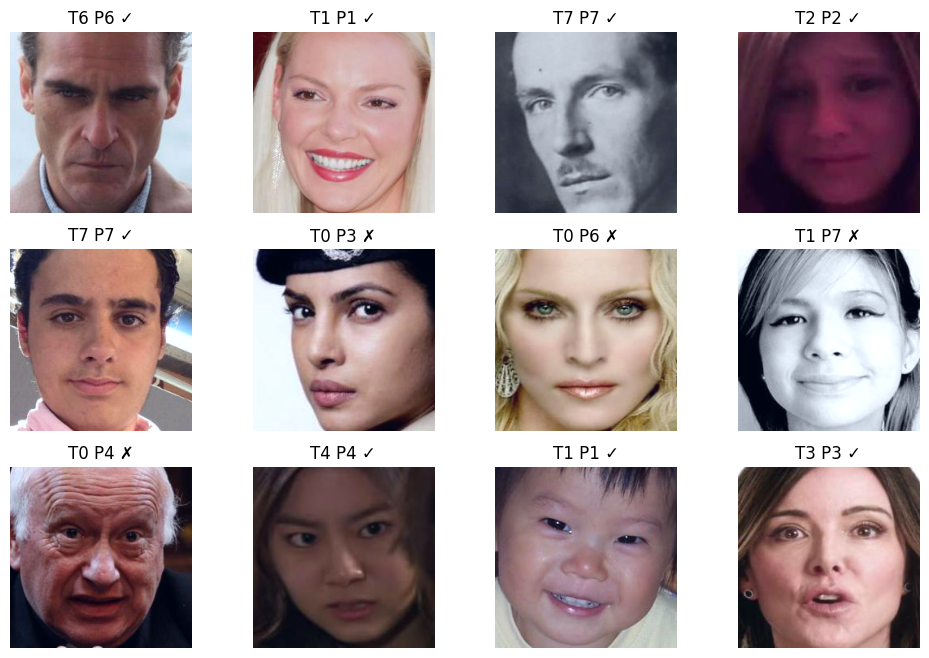

In [9]:
import random

def show_examples(model, loader, device, n=12):
    model.eval()
    imgs, titles = [], []
    with torch.no_grad():
        for batch in loader:
            x, y_cls, _, _, paths = batch
            x = x.to(device)
            logits, _ = model(x)
            pred = logits.argmax(1).cpu().numpy()
            for i in range(len(y_cls)):
                imgs.append(x[i].cpu().permute(1,2,0).numpy())
                correct = (pred[i] == y_cls[i].item())
                titles.append(f"T{y_cls[i].item()} P{pred[i]} {'✓' if correct else '✗'}")
            if len(imgs) >= n: break

    plt.figure(figsize=(12,8))
    for i in range(n):
        plt.subplot(3, n//3, i+1)
        img = (imgs[i]*0.229+0.485)  # unnormalize approx
        plt.imshow(np.clip(img,0,1))
        plt.title(titles[i]); plt.axis("off")
    plt.show()

show_examples(resnet_model, val_loader, device, n=12)
